In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder , OneHotEncoder  , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD


In [10]:
# read data from local file
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\covid_toy.csv")
df 

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


In [11]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [12]:
df["fever"].fillna(df["fever"].mean(), inplace = True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17548\1744649414.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["fever"].fillna(df["fever"].mean(), inplace = True)


In [13]:
# make a target columns
X = df.drop("has_covid", axis=1)
y = df["has_covid"]

In [14]:
# Classify data into Numerical or Categorical
cat = X.select_dtypes(include=["object"]).columns
num = X.select_dtypes(exclude=["object"]).columns

In [15]:
pre = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(drop= "first" , handle_unknown="ignore" ), cat),
        ("num", StandardScaler(),num)
    ]
)
pre

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [16]:

X_train , X_test , y_train , y_test = train_test_split(X,y ,test_size=0.2, random_state=42)

In [17]:
# Fitting data into preprocess
X_train = pre.fit_transform(X_train)
X_test = pre.transform(X_test)

In [18]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [19]:
model = Sequential()
# Input Layer
# model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(32, input_dim =X_train.shape[1], activation='relu'))

# Hidden Layer 2
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
sgd = SGD(
    learning_rate=0.01,
)

model.compile(
    optimizer=sgd,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
m1= model.fit(X_train , y_train , epochs=40 , batch_size=15 , verbose=1 , validation_data= (X_test , y_test), validation_split=0.2)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.6500 - loss: 0.6402 - val_accuracy: 0.4000 - val_loss: 0.6957
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6375 - loss: 0.6396 - val_accuracy: 0.4000 - val_loss: 0.6961
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6375 - loss: 0.6396 - val_accuracy: 0.4000 - val_loss: 0.6961
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6375 - loss: 0.6391 - val_accuracy: 0.4000 - val_loss: 0.6959
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6375 - loss: 0.6390 - val_accuracy: 0.4000 - val_loss: 0.6955
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6375 - loss: 0.6387 - val_accuracy: 0.4000 - val_loss: 0.6954
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6375 - loss: 0.6382 - val_accuracy: 0.4000 - val_loss: 0.6951
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6250 - loss: 0.6380 - val_accuracy: 0.4000 - val_loss: 0.6950

In [55]:
sgd = SGD(
    learning_rate=0.01,
    momentum=0.7
)

model.compile(
    optimizer=sgd,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
m2= model.fit(X_train , y_train , epochs=40 , batch_size=15 , verbose=1 , validation_data= (X_test , y_test), validation_split=0.2)


Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.7000 - loss: 0.6293 - val_accuracy: 0.3500 - val_loss: 0.6966
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6500 - loss: 0.6298 - val_accuracy: 0.3500 - val_loss: 0.7006
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6750 - loss: 0.6272 - val_accuracy: 0.4000 - val_loss: 0.6996
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6750 - loss: 0.6243 - val_accuracy: 0.3500 - val_loss: 0.6965
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7000 - loss: 0.6244 - val_accuracy: 0.3500 - val_loss: 0.6970
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6875 - loss: 0.6222 - val_accuracy: 0.3500 - val_loss: 0.6981
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6875 - loss: 0.6203 - val_accuracy: 0.3500 - val_loss: 0.7001
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6875 - loss: 0.6191 - val_accuracy: 0.3500 - val_loss: 0.7001

In [56]:
sgd = SGD(
    learning_rate=0.01,
    momentum=0.7 , 
    nesterov= True
)

model.compile(
    optimizer=sgd,
    loss='binary_crossentropy',
    metrics=['accuracy']
)
m3= model.fit(X_train , y_train , epochs=40 , batch_size=15 , verbose=1 , validation_data= (X_test , y_test), validation_split=0.2)


Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.7375 - loss: 0.5762 - val_accuracy: 0.4500 - val_loss: 0.7287
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7375 - loss: 0.5751 - val_accuracy: 0.4500 - val_loss: 0.7309
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7500 - loss: 0.5780 - val_accuracy: 0.4500 - val_loss: 0.7302
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 0.5723 - val_accuracy: 0.4500 - val_loss: 0.7239
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7375 - loss: 0.5714 - val_accuracy: 0.4500 - val_loss: 0.7234
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7375 - loss: 0.5699 - val_accuracy: 0.4500 - val_loss: 0.7243
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7250 - loss: 0.5683 - val_accuracy: 0.4500 - val_loss: 0.7271
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7500 - loss: 0.5688 - val_accuracy: 0.4500 - val_loss: 0.7289

In [60]:
model.compile(
    optimizer="adagrad",
    loss='binary_crossentropy',
    metrics=['accuracy']
)
m4= model.fit(X_train , y_train , epochs=40 , batch_size=10 , verbose=1 , validation_data= (X_test , y_test), validation_split=0.2)

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.7625 - loss: 0.5203 - val_accuracy: 0.4500 - val_loss: 0.7417
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7625 - loss: 0.5201 - val_accuracy: 0.4500 - val_loss: 0.7419
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7625 - loss: 0.5197 - val_accuracy: 0.4500 - val_loss: 0.7421
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7625 - loss: 0.5195 - val_accuracy: 0.4500 - val_loss: 0.7423
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7625 - loss: 0.5195 - val_accuracy: 0.4500 - val_loss: 0.7424
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7625 - loss: 0.5192 - val_accuracy: 0.4500 - val_loss: 0.7425
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7625 - loss: 0.5191 - val_accuracy: 0.4500 - val_loss: 0.7426
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7625 - loss: 0.5191 - val_accuracy: 0.4500 - val_loss: 0.7428


In [64]:
# check accuarcy of model
loss, accuracy = model.evaluate(X_train, y_train)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy * 100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7625 - loss: 0.5154 
Loss: 0.5153815150260925
Accuracy: 76.25%


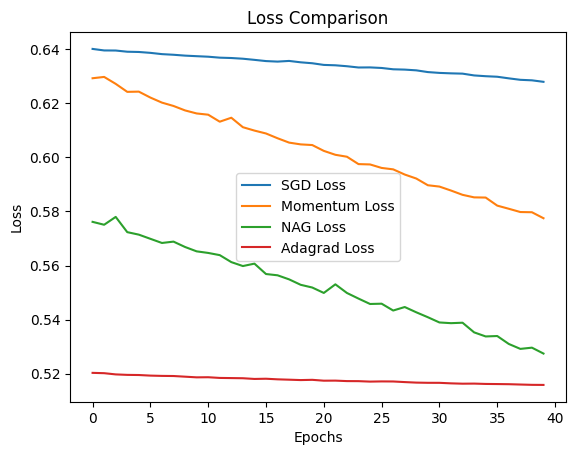

In [61]:
import matplotlib.pyplot as plt

# Loss comparison
plt.plot(m1.history['loss'], label='SGD Loss')
plt.plot(m2.history['loss'], label='Momentum Loss')
plt.plot(m3.history['loss'], label='NAG Loss')
plt.plot(m4.history['loss'], label='Adagrad Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

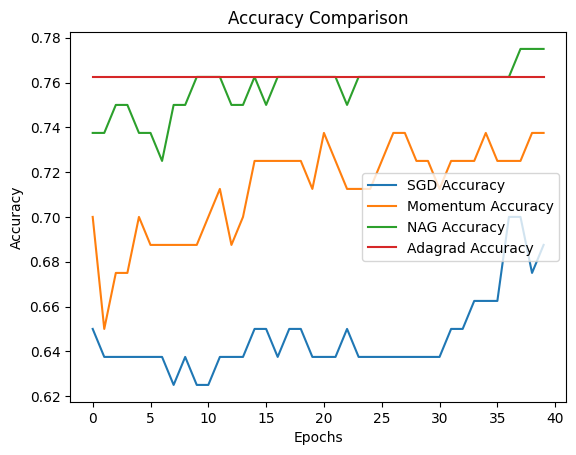

In [62]:
# Accuracy comparison
plt.plot(m1.history['accuracy'], label='SGD Accuracy')
plt.plot(m2.history['accuracy'], label='Momentum Accuracy')
plt.plot(m3.history['accuracy'], label='NAG Accuracy')
plt.plot(m4.history['accuracy'], label='Adagrad Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
